In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import r2_score

In [2]:
X, y = make_regression(
    n_samples=250,
    n_features=20,
    n_informative=12,
    noise=45,
    random_state=42
)

In [3]:
columns = [f"Feature_{i}" for i in range(1,21)]

df = pd.DataFrame(X,columns=columns)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,-1.607560,-0.769142,-0.792420,0.001205,0.659246,-1.239258,0.829475,-0.307962,-0.939903,-0.264515,...,-1.893615,-0.675178,-0.762725,0.937570,-0.193826,0.635418,-0.144519,-2.003862,0.213294,-265.797884
1,-1.016683,-0.039307,-0.329448,0.469268,0.756789,1.328933,0.333860,0.731871,-0.134497,1.081767,...,0.335058,0.679143,-0.244080,0.612469,1.431367,0.622070,-0.302045,-1.312219,0.316156,-30.705804
2,-0.730367,0.045572,0.686260,0.064280,-0.715304,0.852433,2.143944,-1.612716,-0.651600,-2.025143,...,-0.471932,2.314659,0.216459,0.679598,0.633919,-0.661786,-1.867265,0.186454,1.088951,-93.936497
3,-0.176947,-1.379319,1.547505,0.285865,0.658544,1.188393,-0.033127,1.795878,-0.730930,-0.517611,...,-0.612789,0.202923,-0.798297,2.010205,1.794558,-0.016423,-1.515744,0.223788,-0.387702,50.252182
4,1.107081,-2.172670,0.634721,0.672574,-0.132634,-0.435486,-0.535328,1.109700,0.847422,0.331980,...,0.409819,0.350630,-0.120381,-0.974529,-0.090533,0.709452,0.489187,0.190500,-0.241258,261.477611


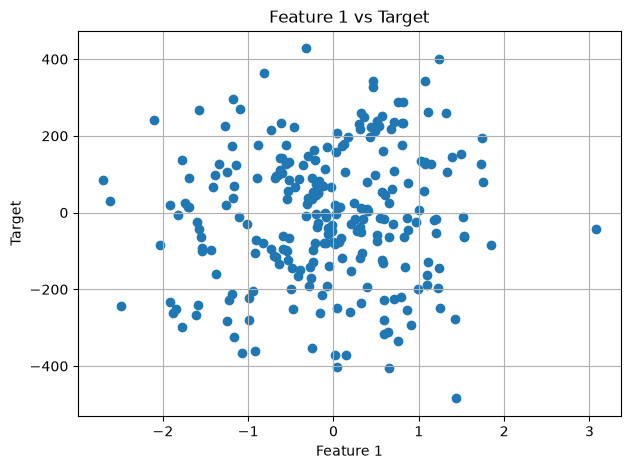

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0],y)

plt.xlabel("Feature 1")

plt.ylabel("Target")

plt.title("Feature 1 vs Target")

plt.grid()

plt.show()

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

In [9]:
ridge = Ridge(alpha=10)

ridge.fit(X_train,y_train)

y_pred_ridge = ridge.predict(X_test)

In [10]:
lasso = Lasso(alpha=0.5)

lasso.fit(X_train,y_train)

y_pred_lasso = lasso.predict(X_test)

In [11]:
elastic = ElasticNet(
    alpha=0.5,
    l1_ratio=0.5,
    random_state=42
)

elastic.fit(X_train,y_train)

y_pred_elastic = elastic.predict(X_test)

In [12]:
print("Linear :",r2_score(y_test,y_pred_lr))

print("Ridge :",r2_score(y_test,y_pred_ridge))

print("Lasso :",r2_score(y_test,y_pred_lasso))

print("Elastic Net :",r2_score(y_test,y_pred_elastic))

Linear : 0.8985327574372415
Ridge : 0.8961537163194675
Lasso : 0.9008207477666874
Elastic Net : 0.8477066633268632


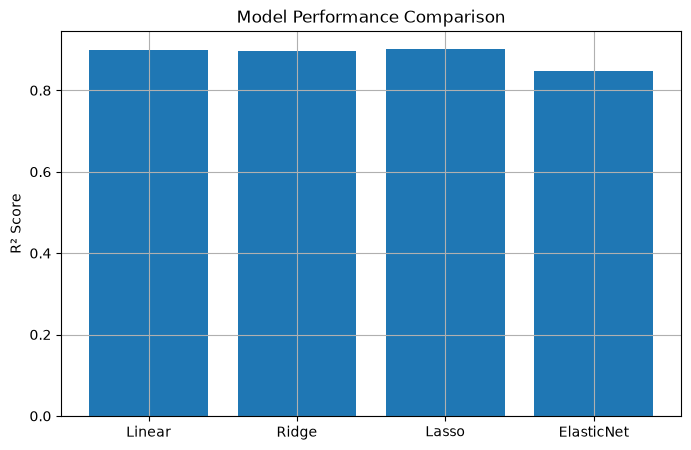

In [13]:
models=["Linear","Ridge","Lasso","ElasticNet"]

scores=[
r2_score(y_test,y_pred_lr),
r2_score(y_test,y_pred_ridge),
r2_score(y_test,y_pred_lasso),
r2_score(y_test,y_pred_elastic)
]

plt.figure(figsize=(8,5))

plt.bar(models,scores)

plt.ylabel("R² Score")

plt.title("Model Performance Comparison")

plt.grid()

plt.show()

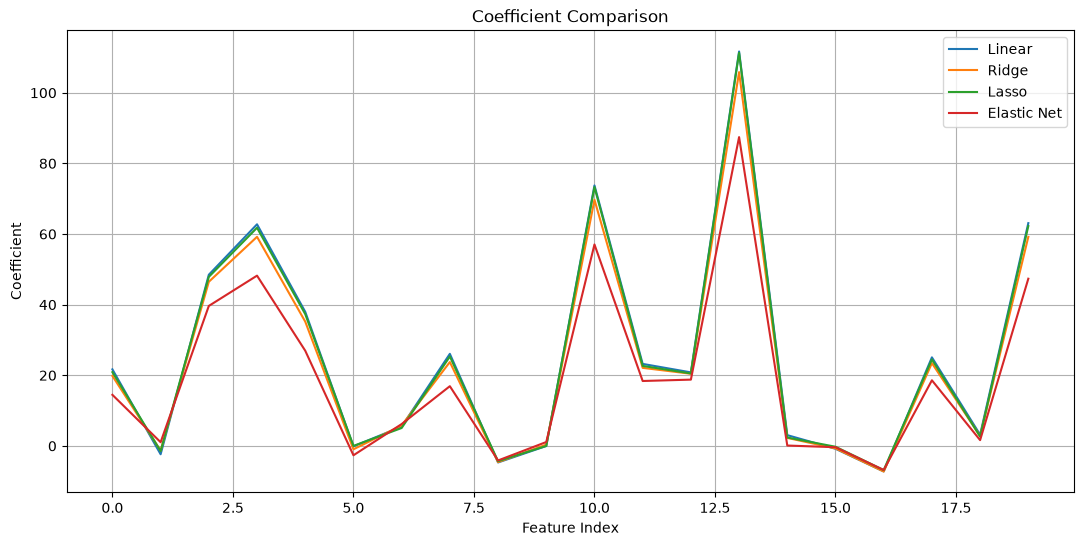

In [14]:
plt.figure(figsize=(13,6))

plt.plot(lr.coef_,label="Linear")

plt.plot(ridge.coef_,label="Ridge")

plt.plot(lasso.coef_,label="Lasso")

plt.plot(elastic.coef_,label="Elastic Net")

plt.legend()

plt.xlabel("Feature Index")

plt.ylabel("Coefficient")

plt.title("Coefficient Comparison")

plt.grid()

plt.show()

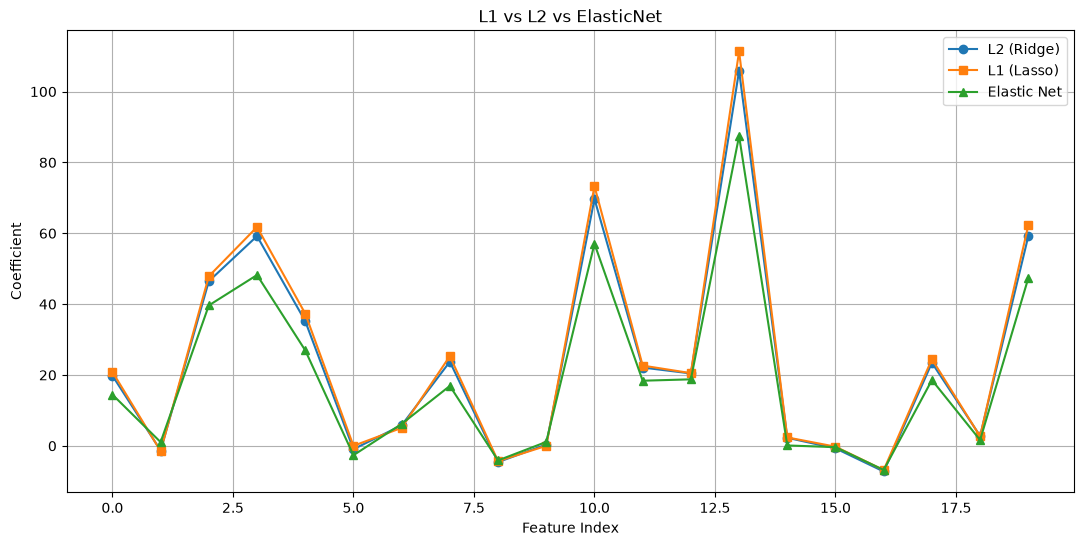

In [15]:
plt.figure(figsize=(13,6))

plt.plot(ridge.coef_,marker='o',label="L2 (Ridge)")

plt.plot(lasso.coef_,marker='s',label="L1 (Lasso)")

plt.plot(elastic.coef_,marker='^',label="Elastic Net")

plt.xlabel("Feature Index")

plt.ylabel("Coefficient")

plt.title("L1 vs L2 vs ElasticNet")

plt.legend()

plt.grid()

plt.show()

In [16]:
print("Lasso Selected Features :",np.sum(lasso.coef_!=0))

print("Elastic Selected Features :",np.sum(elastic.coef_!=0))

Lasso Selected Features : 18
Elastic Selected Features : 20


In [17]:
print("Lasso Removed :",np.sum(lasso.coef_==0))

print("Elastic Removed :",np.sum(elastic.coef_==0))

Lasso Removed : 2
Elastic Removed : 0


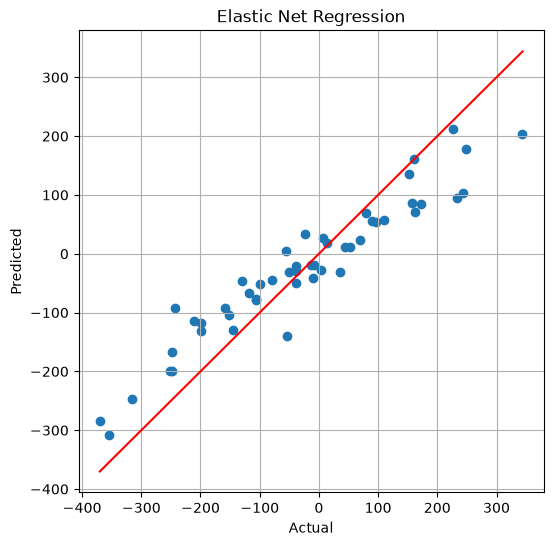

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_elastic)

plt.plot(
[y_test.min(),y_test.max()],
[y_test.min(),y_test.max()],
'r'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Elastic Net Regression")

plt.grid()

plt.show()

In [19]:
alphas=[0.001,0.01,0.1,1,10,100]

scores=[]

for a in alphas:

    model=ElasticNet(
        alpha=a,
        l1_ratio=0.5,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    scores.append(r2_score(y_test,pred))

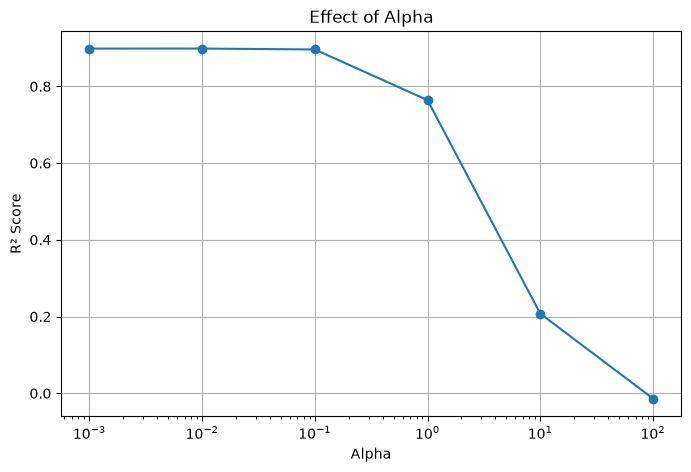

In [20]:
plt.figure(figsize=(8,5))

plt.plot(alphas,scores,marker="o")

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("R² Score")

plt.title("Effect of Alpha")

plt.grid()

plt.show()

In [21]:
ratios=[0.1,0.3,0.5,0.7,0.9]

scores=[]

for r in ratios:

    model=ElasticNet(
        alpha=0.5,
        l1_ratio=r,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    scores.append(r2_score(y_test,pred))

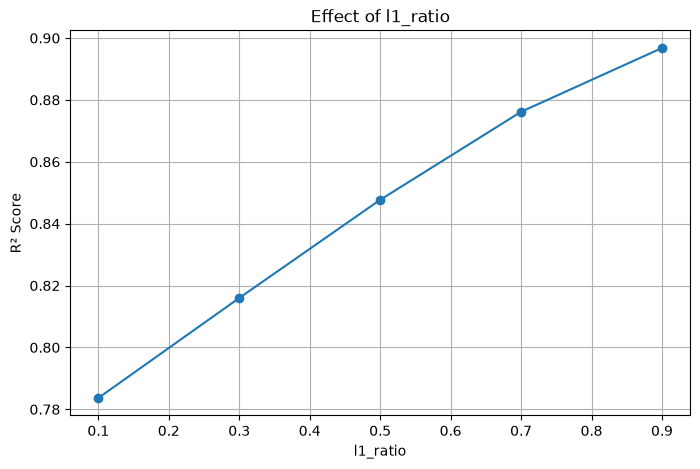

In [22]:
plt.figure(figsize=(8,5))

plt.plot(ratios,scores,marker='o')

plt.xlabel("l1_ratio")

plt.ylabel("R² Score")

plt.title("Effect of l1_ratio")

plt.grid()

plt.show()

In [23]:
remaining=[]

for r in ratios:

    model=ElasticNet(
        alpha=0.5,
        l1_ratio=r,
        random_state=42
    )

    model.fit(X_train,y_train)

    remaining.append(np.sum(model.coef_!=0))

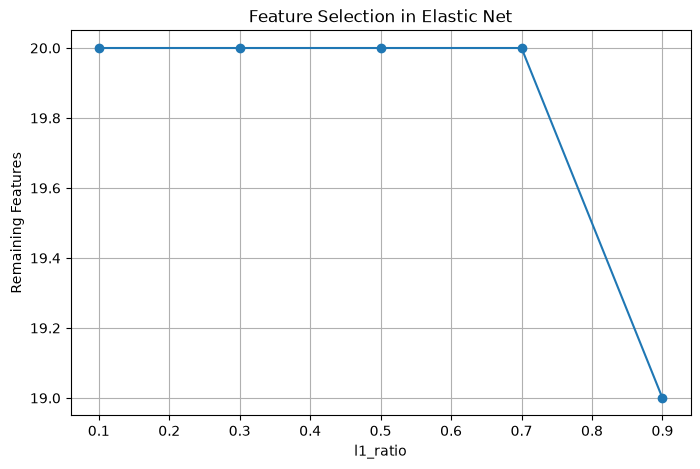

In [24]:
plt.figure(figsize=(8,5))

plt.plot(ratios,remaining,marker='o')

plt.xlabel("l1_ratio")

plt.ylabel("Remaining Features")

plt.title("Feature Selection in Elastic Net")

plt.grid()

plt.show()

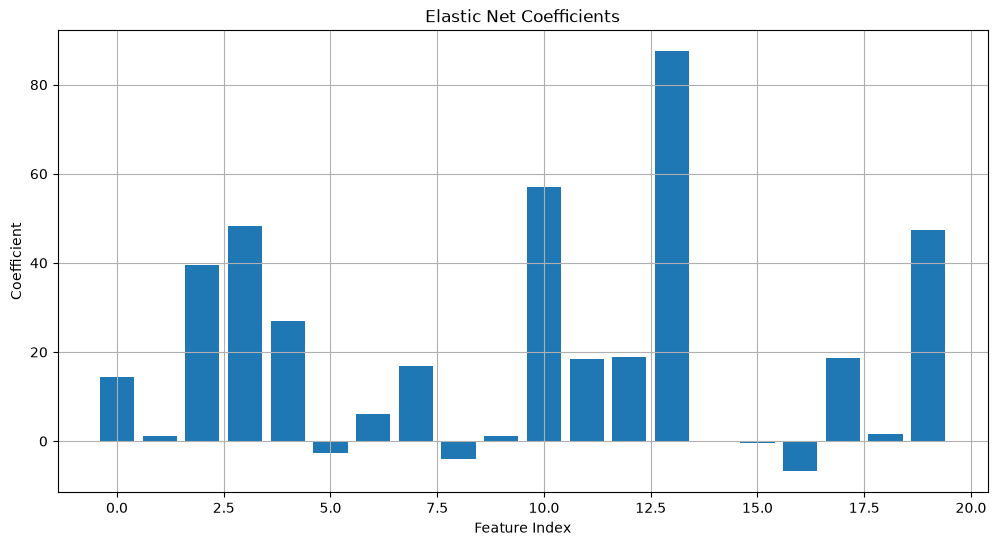

In [25]:
plt.figure(figsize=(12,6))

plt.bar(np.arange(len(elastic.coef_)),elastic.coef_)

plt.xlabel("Feature Index")

plt.ylabel("Coefficient")

plt.title("Elastic Net Coefficients")

plt.grid()

plt.show()

In [26]:
comparison = pd.DataFrame({

    "Model":["Linear","Ridge","Lasso","Elastic Net"],

    "R² Score":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_lasso),
        r2_score(y_test,y_pred_elastic)
    ],

    "Selected Features":[
        len(lr.coef_),
        len(ridge.coef_),
        np.sum(lasso.coef_!=0),
        np.sum(elastic.coef_!=0)
    ]
})

comparison

,Model,R² Score,Selected Features
0,Linear,0.898533,20
1,Ridge,0.896154,20
2,Lasso,0.900821,18
3,Elastic Net,0.847707,20


In [27]:
from sklearn.linear_model import ElasticNetCV

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=np.logspace(-3, 2, 20),
    cv=5,
    random_state=42
)

elastic_cv.fit(X_train, y_train)

print("Best Alpha :", elastic_cv.alpha_)
print("Best l1_ratio :", elastic_cv.l1_ratio_)

y_pred_cv = elastic_cv.predict(X_test)

print("ElasticNetCV R² Score :", r2_score(y_test, y_pred_cv))

Best Alpha : 0.12742749857031335
Best l1_ratio : 0.9
ElasticNetCV R² Score : 0.8989593573783397
